In [26]:
# ============================================================
# DEEP LEARNING — EVALUATION, VISUALIZATION & EXPLAINABILITY
# RNN / LSTM / BiLSTM
# ============================================================

import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# BASE DIRECTORY
# ------------------------------------------------------------
BASE_DIR = "/content/mydrive/MyDrive/NLP_Research_Project"

# ------------------------------------------------------------
# INPUT FILES
# ------------------------------------------------------------
TRAIN_PATH = os.path.join(
    BASE_DIR, "data", "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE_DIR, "data", "splits", "validation.csv"
)

TEST_PATH = os.path.join(
    BASE_DIR, "data", "splits", "test.csv"
)

# ------------------------------------------------------------
# TRAINED MODELS
# ------------------------------------------------------------
MODEL_DIR = os.path.join(
    BASE_DIR, "models", "deep_learning"
)

MODEL_PATHS = {
    "RNN": os.path.join(MODEL_DIR, "rnn_best.keras"),
    "LSTM": os.path.join(MODEL_DIR, "lstm_best.keras"),
    "BiLSTM": os.path.join(MODEL_DIR, "bilstm_best.keras")
}

# ------------------------------------------------------------
# EVALUATION OUTPUT DIRECTORY
# ------------------------------------------------------------
EVAL_DIR = os.path.join(
    BASE_DIR, "results", "deep_learning_evaluation"
)

FIG_DIR = os.path.join(EVAL_DIR, "figures")
METRICS_DIR = os.path.join(EVAL_DIR, "metrics")
CM_DIR = os.path.join(EVAL_DIR, "confusion_matrices")
ERROR_DIR = os.path.join(EVAL_DIR, "error_analysis")
EXPLAIN_DIR = os.path.join(EVAL_DIR, "explainability")
SHAP_DIR = os.path.join(EXPLAIN_DIR, "shap")
LIME_DIR = os.path.join(EXPLAIN_DIR, "lime")
STATS_DIR = os.path.join(EVAL_DIR, "statistical_tests")

for folder in [
    EVAL_DIR,
    FIG_DIR,
    METRICS_DIR,
    CM_DIR,
    ERROR_DIR,
    EXPLAIN_DIR,
    SHAP_DIR,
    LIME_DIR,
    STATS_DIR
]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------------------
# DATA / MODEL CONFIG
# Must match your friend's training code
# ------------------------------------------------------------
TEXT_COL = "text"
LABEL_COL = "label"

VOCAB_SIZE = 20000
MAX_LEN = 300
OOV_TOKEN = "<OOV>"

print("=" * 80)
print("DEEP LEARNING EVALUATION PIPELINE")
print("=" * 80)

print("\nBASE DIRECTORY:")
print(BASE_DIR)

print("\nEvaluation directory:")
print(EVAL_DIR)

DEEP LEARNING EVALUATION PIPELINE

BASE DIRECTORY:
/content/mydrive/MyDrive/NLP_Research_Project

Evaluation directory:
/content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation


In [27]:
# ============================================================
# VERIFY REQUIRED FILES
# ============================================================

required_files = {
    "Train": TRAIN_PATH,
    "Validation": VAL_PATH,
    "Test": TEST_PATH,
    "RNN model": MODEL_PATHS["RNN"],
    "LSTM model": MODEL_PATHS["LSTM"],
    "BiLSTM model": MODEL_PATHS["BiLSTM"],
}

print("\n" + "=" * 80)
print("CHECKING REQUIRED ARTIFACTS")
print("=" * 80)

all_exist = True

for name, path in required_files.items():

    exists = os.path.exists(path)

    if exists:
        print(f"✓ {name}")
        print(f"  {path}")
    else:
        print(f"✗ {name}")
        print(f"  {path}")
        all_exist = False

if not all_exist:
    raise FileNotFoundError(
        "\nSome required files are missing. "
        "Check the paths printed above."
    )

print("\n✓ All required artifacts found.")


CHECKING REQUIRED ARTIFACTS
✓ Train
  /content/mydrive/MyDrive/NLP_Research_Project/data/splits/train.csv
✓ Validation
  /content/mydrive/MyDrive/NLP_Research_Project/data/splits/validation.csv
✓ Test
  /content/mydrive/MyDrive/NLP_Research_Project/data/splits/test.csv
✓ RNN model
  /content/mydrive/MyDrive/NLP_Research_Project/models/deep_learning/rnn_best.keras
✓ LSTM model
  /content/mydrive/MyDrive/NLP_Research_Project/models/deep_learning/lstm_best.keras
✓ BiLSTM model
  /content/mydrive/MyDrive/NLP_Research_Project/models/deep_learning/bilstm_best.keras

✓ All required artifacts found.


In [28]:
# ============================================================
# LOAD DATA
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())

print("\nValidation label distribution:")
print(val_df[LABEL_COL].value_counts())

print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts())

DATASET INFORMATION
Train shape: (6425, 4)
Validation shape: (1377, 4)
Test shape: (1377, 4)

Columns:
['id', 'raw_text', 'text', 'label']

Train label distribution:
label
2    5126
3     498
0     423
1     176
4     150
6      32
5      20
Name: count, dtype: int64

Validation label distribution:
label
2    1098
3     107
0      91
1      38
4      32
6       7
5       4
Name: count, dtype: int64

Test label distribution:
label
2    1099
3     106
0      91
1      38
4      32
6       6
5       5
Name: count, dtype: int64


In [29]:
# ============================================================
# RECREATE TOKENIZER
# ============================================================

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(
    train_df[TEXT_COL].astype(str)
)

print("=" * 80)
print("TOKENIZER")
print("=" * 80)

print("Vocabulary size:", len(tokenizer.word_index))

def texts_to_padded(texts):
    sequences = tokenizer.texts_to_sequences(
        texts.astype(str)
    )

    return pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

X_test = texts_to_padded(test_df[TEXT_COL])

print("X_test shape:", X_test.shape)

TOKENIZER
Vocabulary size: 2256
X_test shape: (1377, 300)


In [30]:
# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

label_encoder.fit(
    train_df[LABEL_COL]
)

class_names = [str(x) for x in label_encoder.classes_]

print("=" * 80)
print("CLASS INFORMATION")
print("=" * 80)

print("Classes:")
for i, cls in enumerate(class_names):
    print(i, "→", cls)

print("\nNumber of classes:", len(class_names))

# Check whether test contains unseen labels
unseen_test_labels = set(test_df[LABEL_COL]) - set(train_df[LABEL_COL])

if unseen_test_labels:
    raise ValueError(
        f"Test set contains labels not present in training set: "
        f"{unseen_test_labels}"
    )

y_test = label_encoder.transform(
    test_df[LABEL_COL]
)

print("\ny_test shape:", y_test.shape)

CLASS INFORMATION
Classes:
0 → 0
1 → 1
2 → 2
3 → 3
4 → 4
5 → 5
6 → 6

Number of classes: 7

y_test shape: (1377,)


In [31]:
# ============================================================
# LOAD TRAINED MODELS
# ============================================================

models = {}

for model_name, model_path in MODEL_PATHS.items():

    print("\n" + "=" * 60)
    print("Loading:", model_name)
    print("=" * 60)

    models[model_name] = load_model(model_path)

    print("✓ Loaded successfully")
    print("Input shape:", models[model_name].input_shape)
    print("Output shape:", models[model_name].output_shape)


Loading: RNN
✓ Loaded successfully
Input shape: (None, 300)
Output shape: (None, 7)

Loading: LSTM
✓ Loaded successfully
Input shape: (None, 300)
Output shape: (None, 7)

Loading: BiLSTM
✓ Loaded successfully
Input shape: (None, 300)
Output shape: (None, 7)


In [32]:
# ============================================================
# GENERATE TEST PREDICTIONS
# ============================================================

predictions = {}
probabilities = {}

for model_name, model in models.items():

    print(f"\nGenerating predictions: {model_name}")

    probs = model.predict(
        X_test,
        batch_size=32,
        verbose=1
    )

    preds = np.argmax(probs, axis=1)

    probabilities[model_name] = probs
    predictions[model_name] = preds

    print(
        f"{model_name}: "
        f"{len(preds)} predictions generated"
    )

print("\n✓ Predictions generated for all models.")


Generating predictions: RNN
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step
RNN: 1377 predictions generated

Generating predictions: LSTM
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step
LSTM: 1377 predictions generated

Generating predictions: BiLSTM
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 558ms/step
BiLSTM: 1377 predictions generated

✓ Predictions generated for all models.


In [33]:
# ============================================================
# EVALUATION METRICS
# ============================================================

evaluation_results = {}

for model_name in models:

    preds = predictions[model_name]
    probs = probabilities[model_name]

    accuracy = accuracy_score(
        y_test,
        preds
    )

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_test,
            preds,
            average="macro",
            zero_division=0
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            y_test,
            preds,
            average="weighted",
            zero_division=0
        )
    )

    # Multiclass ROC-AUC
    try:
        roc_auc = roc_auc_score(
            y_test,
            probs,
            multi_class="ovr",
            average="macro"
        )
    except:
        roc_auc = np.nan

    evaluation_results[model_name] = {
        "Accuracy": float(accuracy),
        "Precision_macro": float(precision_macro),
        "Recall_macro": float(recall_macro),
        "F1_macro": float(f1_macro),
        "Precision_weighted": float(precision_weighted),
        "Recall_weighted": float(recall_weighted),
        "F1_weighted": float(f1_weighted),
        "ROC_AUC_macro": float(roc_auc)
    }

comparison_df = pd.DataFrame(
    evaluation_results
).T

comparison_df = comparison_df.sort_values(
    "F1_macro",
    ascending=False
)

print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

display(
    comparison_df.round(4)
)


MODEL EVALUATION


,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC_macro
BiLSTM,0.8983,0.5245,0.5449,0.5344,0.8942,0.8983,0.8962,0.9656
LSTM,0.9027,0.5303,0.5326,0.5309,0.8952,0.9027,0.8988,0.9712
RNN,0.8722,0.3944,0.4327,0.4114,0.8513,0.8722,0.8608,0.9487


In [34]:
# ============================================================
# SAVE METRICS
# ============================================================

comparison_path = os.path.join(
    METRICS_DIR,
    "dl_evaluation_comparison.csv"
)

comparison_df.to_csv(
    comparison_path
)

metrics_json_path = os.path.join(
    METRICS_DIR,
    "dl_evaluation_metrics.json"
)

with open(metrics_json_path, "w") as f:
    json.dump(
        evaluation_results,
        f,
        indent=4
    )

print("Saved:")
print(comparison_path)
print(metrics_json_path)

Saved:
/content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation/metrics/dl_evaluation_comparison.csv
/content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation/metrics/dl_evaluation_metrics.json


In [35]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

classification_reports = {}

for model_name in models:

    report = classification_report(
        y_test,
        predictions[model_name],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    classification_reports[model_name] = report

    report_df = pd.DataFrame(report).T

    path = os.path.join(
        METRICS_DIR,
        f"{model_name.lower()}_classification_report.csv"
    )

    report_df.to_csv(path)

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    display(
        report_df.round(4)
    )


RNN


,precision,recall,f1-score,support
0,0.5785,0.7692,0.6604,91.0000
1,0.8293,0.8947,0.8608,38.0000
2,0.9513,0.9591,0.9551,1099.0000
3,0.4019,0.4057,0.4038,106.0000
4,0.0000,0.0000,0.0000,32.0000
5,0.0000,0.0000,0.0000,5.0000
6,0.0000,0.0000,0.0000,6.0000
accuracy,0.8722,0.8722,0.8722,0.8722
macro avg,0.3944,0.4327,0.4114,1377.0000
weighted avg,0.8513,0.8722,0.8608,1377.0000



LSTM


,precision,recall,f1-score,support
0,0.7579,0.7912,0.7742,91.0000
1,0.8857,0.8158,0.8493,38.0000
2,0.9586,0.9682,0.9633,1099.0000
3,0.5545,0.5283,0.5411,106.0000
4,0.5556,0.6250,0.5882,32.0000
5,0.0000,0.0000,0.0000,5.0000
6,0.0000,0.0000,0.0000,6.0000
accuracy,0.9027,0.9027,0.9027,0.9027
macro avg,0.5303,0.5326,0.5309,1377.0000
weighted avg,0.8952,0.9027,0.8988,1377.0000



BiLSTM


,precision,recall,f1-score,support
0,0.7835,0.8352,0.8085,91.0000
1,0.8250,0.8684,0.8462,38.0000
2,0.9616,0.9572,0.9594,1099.0000
3,0.4956,0.5283,0.5114,106.0000
4,0.6061,0.6250,0.6154,32.0000
5,0.0000,0.0000,0.0000,5.0000
6,0.0000,0.0000,0.0000,6.0000
accuracy,0.8983,0.8983,0.8983,0.8983
macro avg,0.5245,0.5449,0.5344,1377.0000
weighted avg,0.8942,0.8983,0.8962,1377.0000


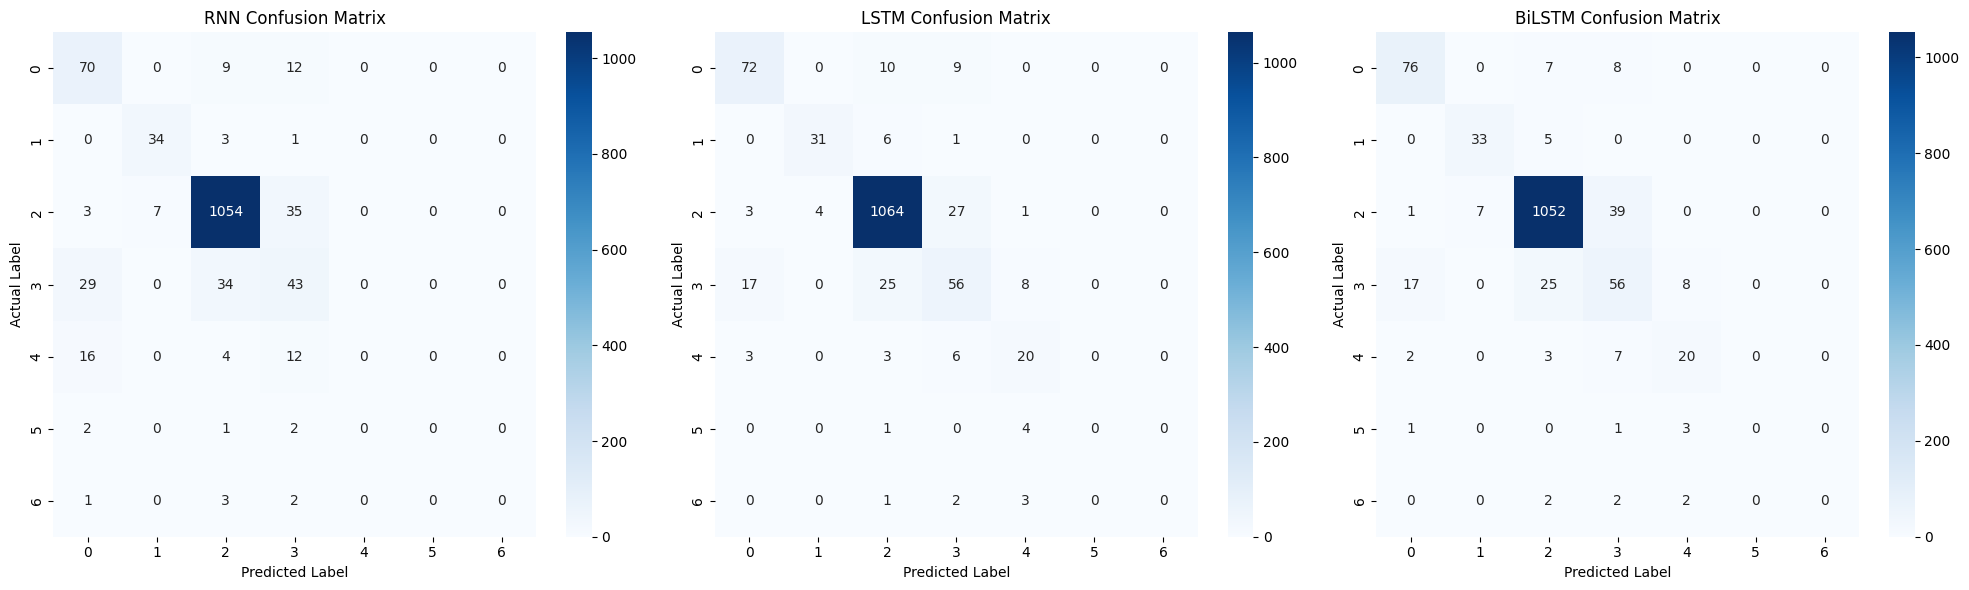

Saved: /content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation/confusion_matrices/all_models_confusion_matrices.png


In [36]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

for ax, model_name in zip(axes, models):

    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(
        f"{model_name} Confusion Matrix"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()

cm_path = os.path.join(
    CM_DIR,
    "all_models_confusion_matrices.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", cm_path)

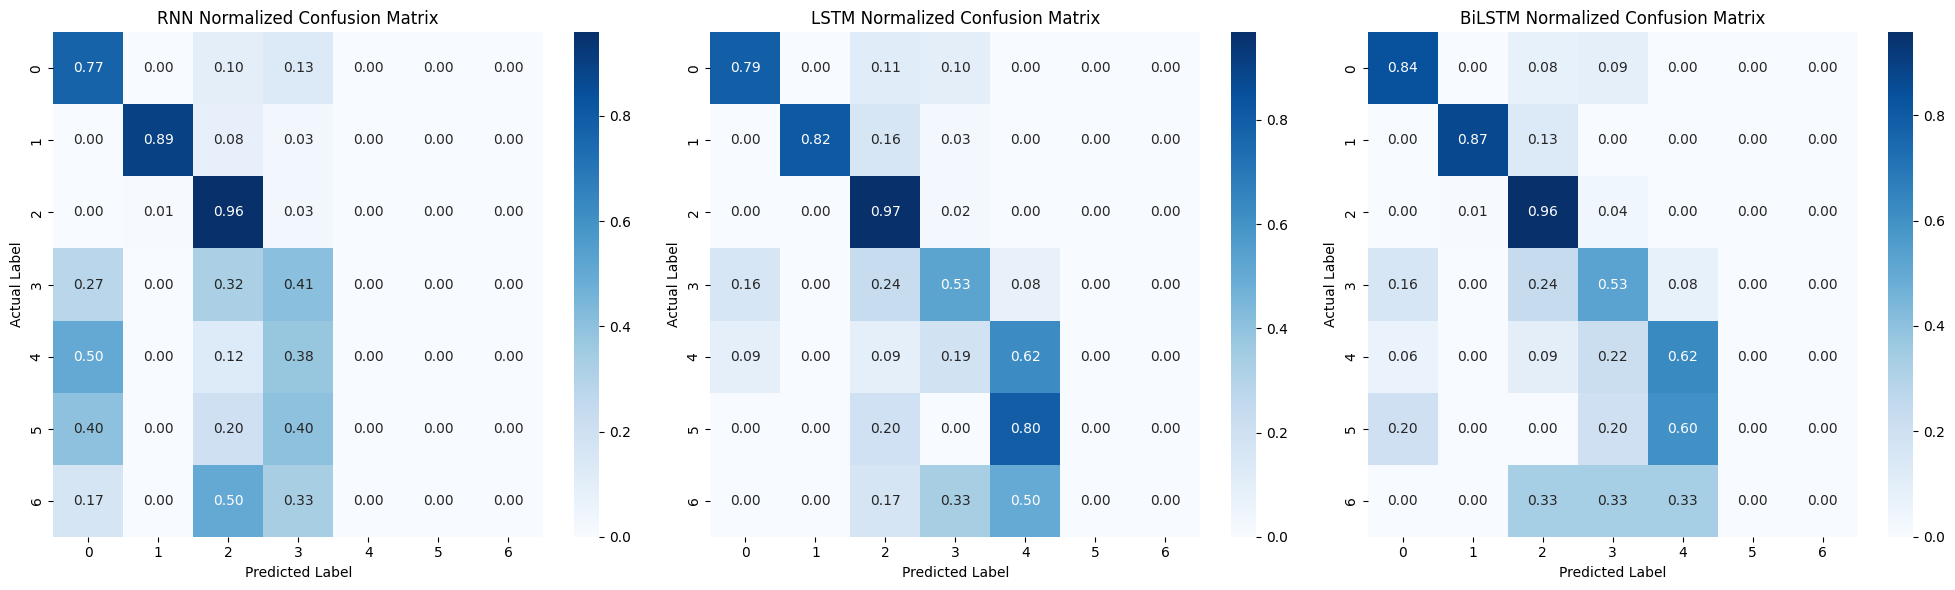

In [37]:
# ============================================================
# NORMALIZED CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

for ax, model_name in zip(axes, models):

    cm = confusion_matrix(
        y_test,
        predictions[model_name],
        normalize="true"
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(
        f"{model_name} Normalized Confusion Matrix"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()

path = os.path.join(
    CM_DIR,
    "normalized_confusion_matrices.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

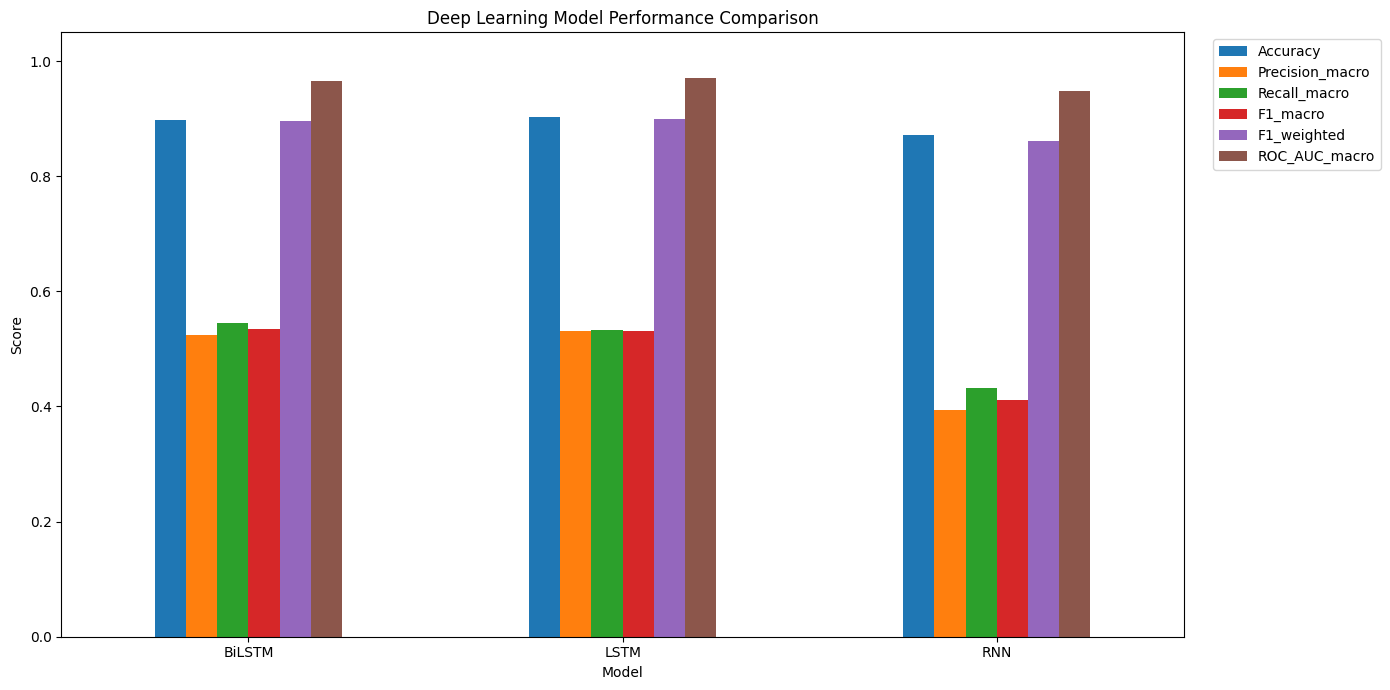

In [38]:
# ============================================================
# MODEL COMPARISON — ALL METRICS
# ============================================================

plot_df = comparison_df[
    [
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "F1_weighted",
        "ROC_AUC_macro"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Deep Learning Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "dl_model_comparison.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

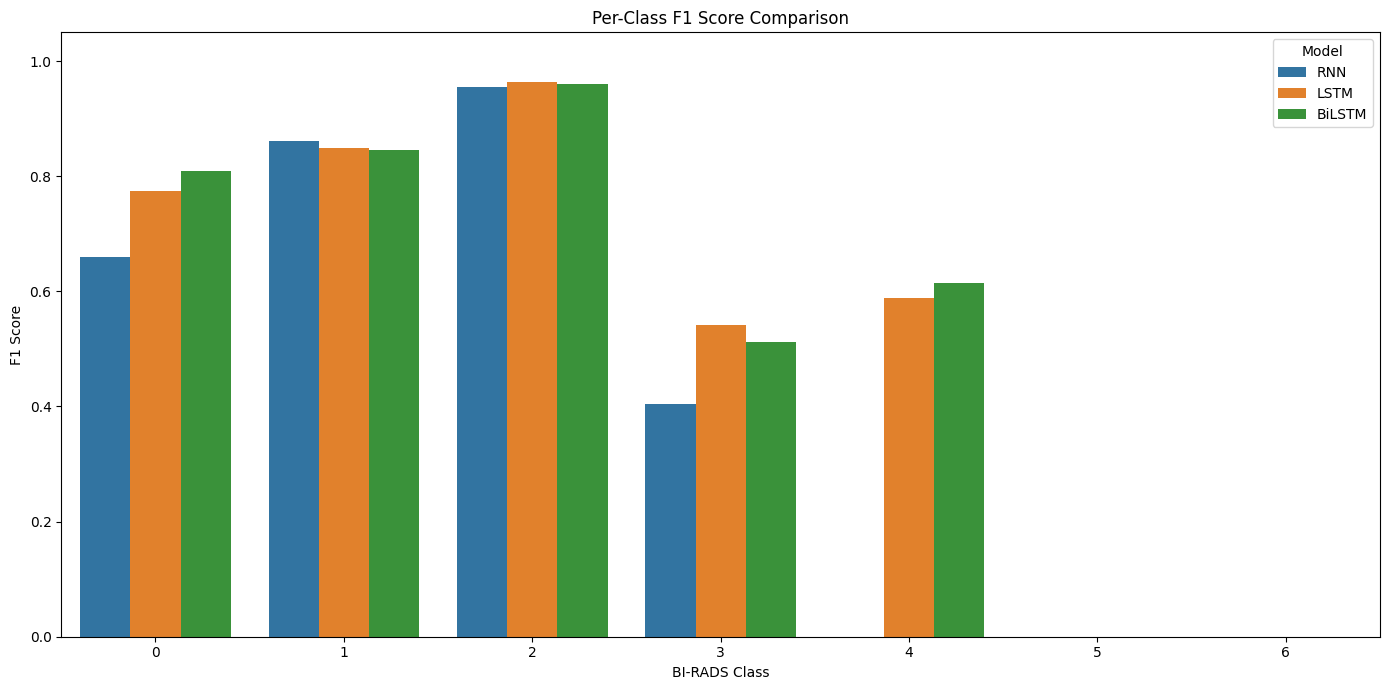

In [39]:
# ============================================================
# PER-CLASS F1 SCORE COMPARISON
# ============================================================

f1_rows = []

for model_name in models:

    report = classification_reports[model_name]

    for cls in class_names:

        f1_rows.append({
            "Model": model_name,
            "Class": cls,
            "F1": report[cls]["f1-score"]
        })

f1_df = pd.DataFrame(f1_rows)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=f1_df,
    x="Class",
    y="F1",
    hue="Model"
)

plt.title(
    "Per-Class F1 Score Comparison"
)

plt.ylabel("F1 Score")
plt.xlabel("BI-RADS Class")
plt.ylim(0, 1.05)

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "per_class_f1_comparison.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

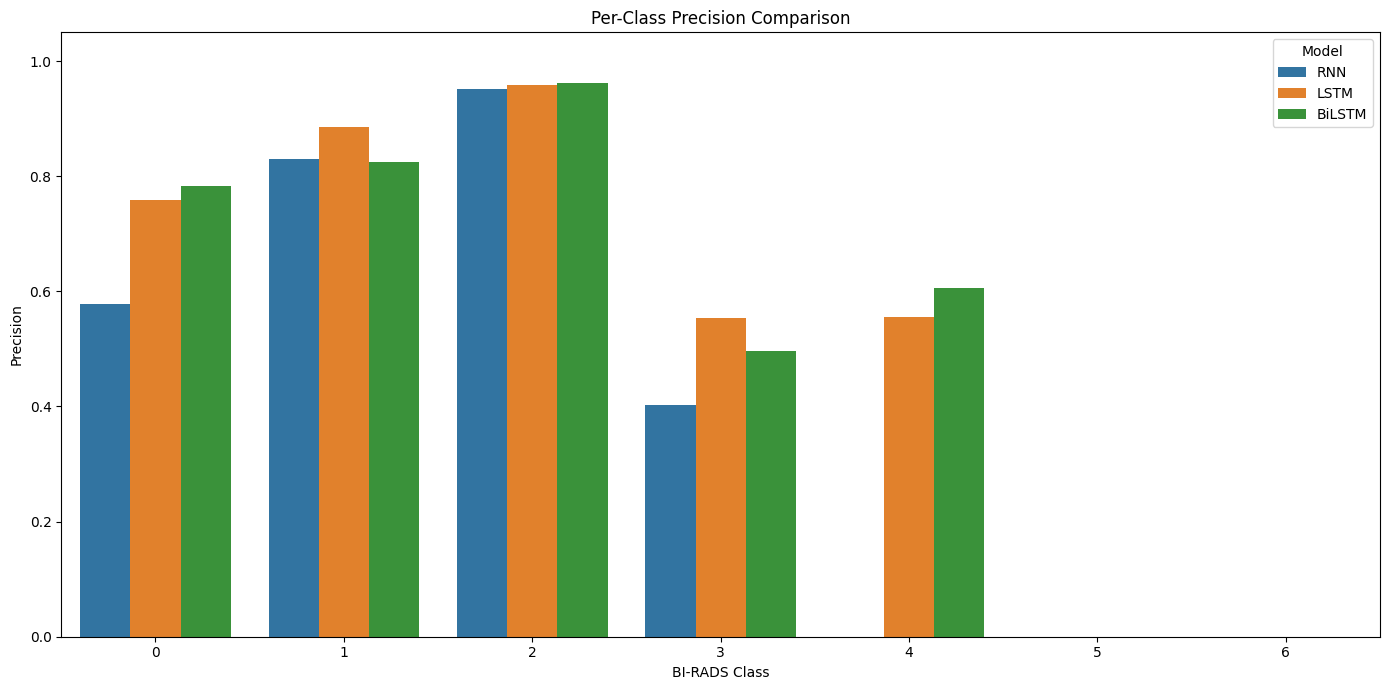

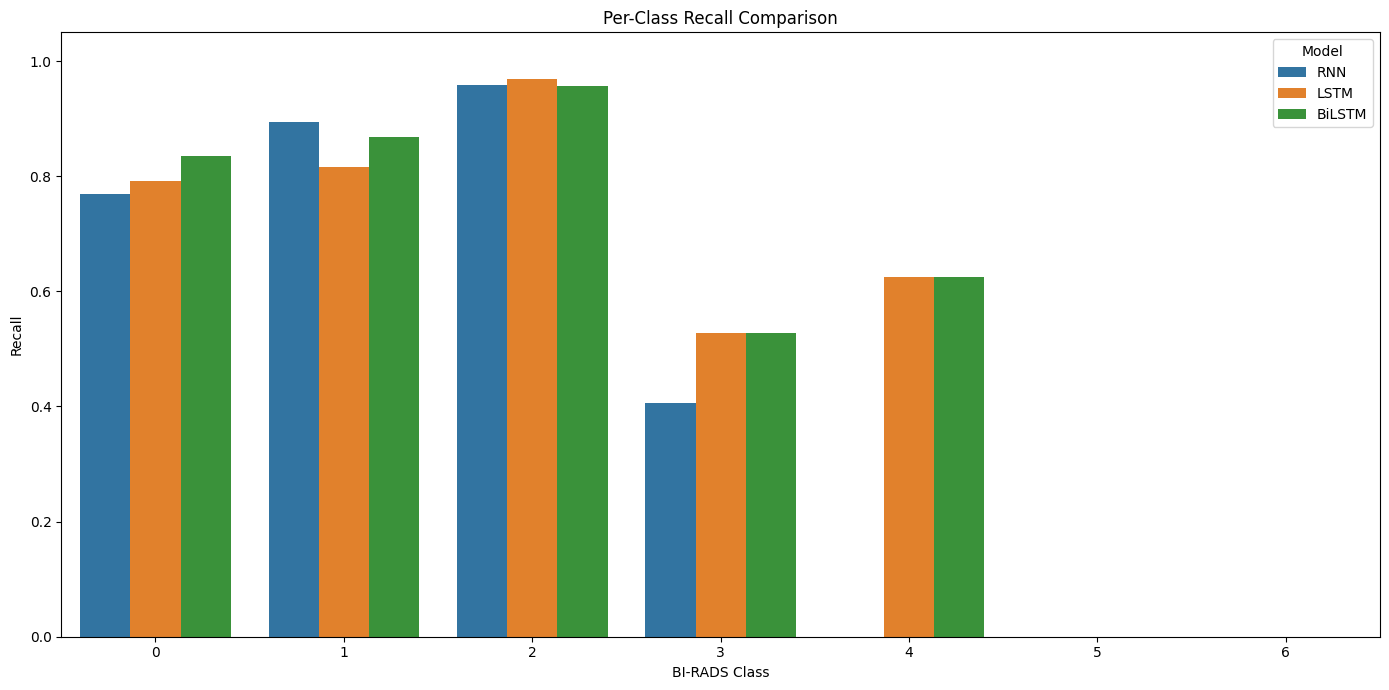

In [40]:
# ============================================================
# PER-CLASS PRECISION / RECALL
# ============================================================

pr_rows = []

for model_name in models:

    report = classification_reports[model_name]

    for cls in class_names:

        pr_rows.append({
            "Model": model_name,
            "Class": cls,
            "Precision": report[cls]["precision"],
            "Recall": report[cls]["recall"]
        })

pr_df = pd.DataFrame(pr_rows)

for metric in ["Precision", "Recall"]:

    plt.figure(figsize=(14, 7))

    sns.barplot(
        data=pr_df,
        x="Class",
        y=metric,
        hue="Model"
    )

    plt.title(
        f"Per-Class {metric} Comparison"
    )

    plt.ylabel(metric)
    plt.xlabel("BI-RADS Class")
    plt.ylim(0, 1.05)

    plt.tight_layout()

    path = os.path.join(
        FIG_DIR,
        f"per_class_{metric.lower()}_comparison.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

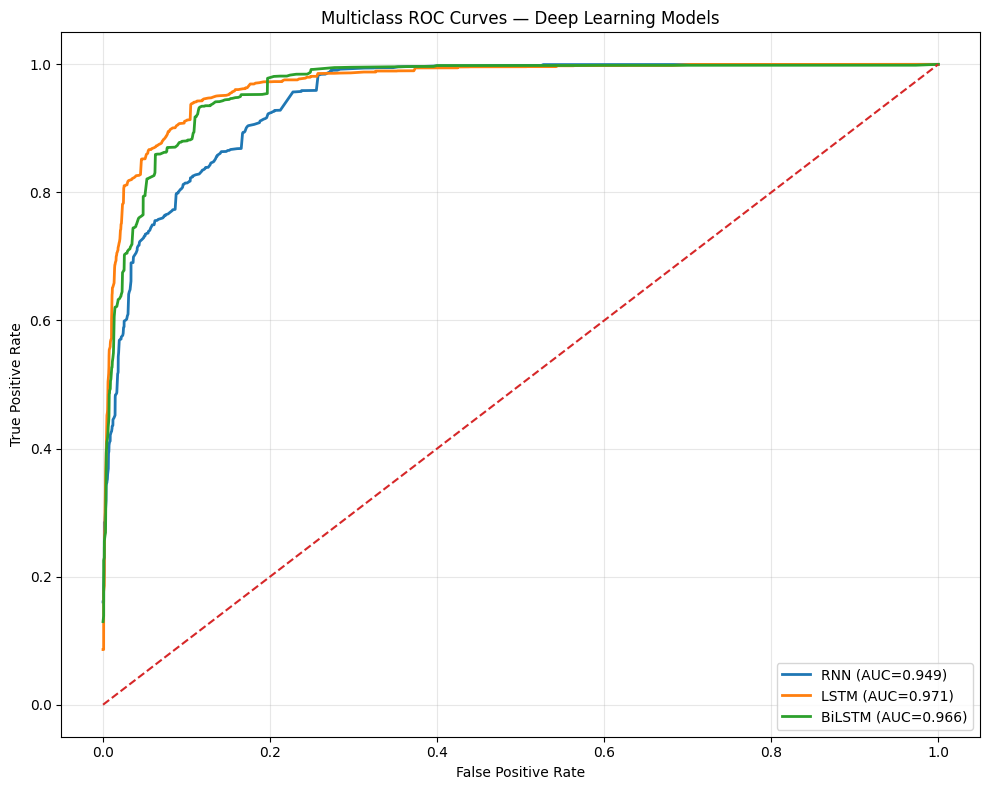

In [41]:
# ============================================================
# MULTICLASS ROC CURVES
# ============================================================

n_classes = len(class_names)

y_test_binary = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

plt.figure(figsize=(10, 8))

for model_name in models:

    probs = probabilities[model_name]

    # Macro-average ROC
    fpr = {}
    tpr = {}

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            probs[:, i]
        )

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(n_classes)]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= n_classes

    roc_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Multiclass ROC Curves — Deep Learning Models"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "multiclass_roc_curves.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

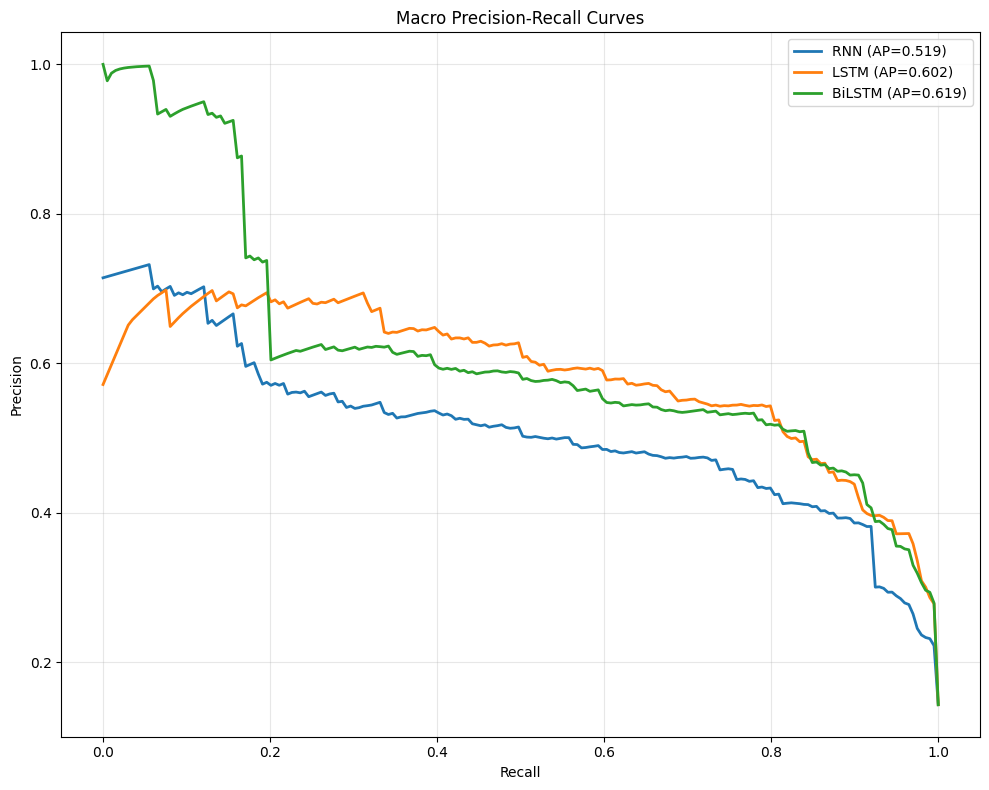

In [42]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(10, 8))

for model_name in models:

    probs = probabilities[model_name]

    precision_macro = []
    recall_macro = []

    for i in range(n_classes):

        precision, recall, _ = precision_recall_curve(
            y_test_binary[:, i],
            probs[:, i]
        )

        precision_macro.append(
            np.interp(
                np.linspace(0, 1, 200),
                recall[::-1],
                precision[::-1]
            )
        )

        recall_macro.append(
            np.linspace(0, 1, 200)
        )

    mean_precision = np.mean(
        precision_macro,
        axis=0
    )

    mean_recall = np.linspace(
        0, 1, 200
    )

    ap = average_precision_score(
        y_test_binary,
        probs,
        average="macro"
    )

    plt.plot(
        mean_recall,
        mean_precision,
        linewidth=2,
        label=f"{model_name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Macro Precision-Recall Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "precision_recall_curves.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

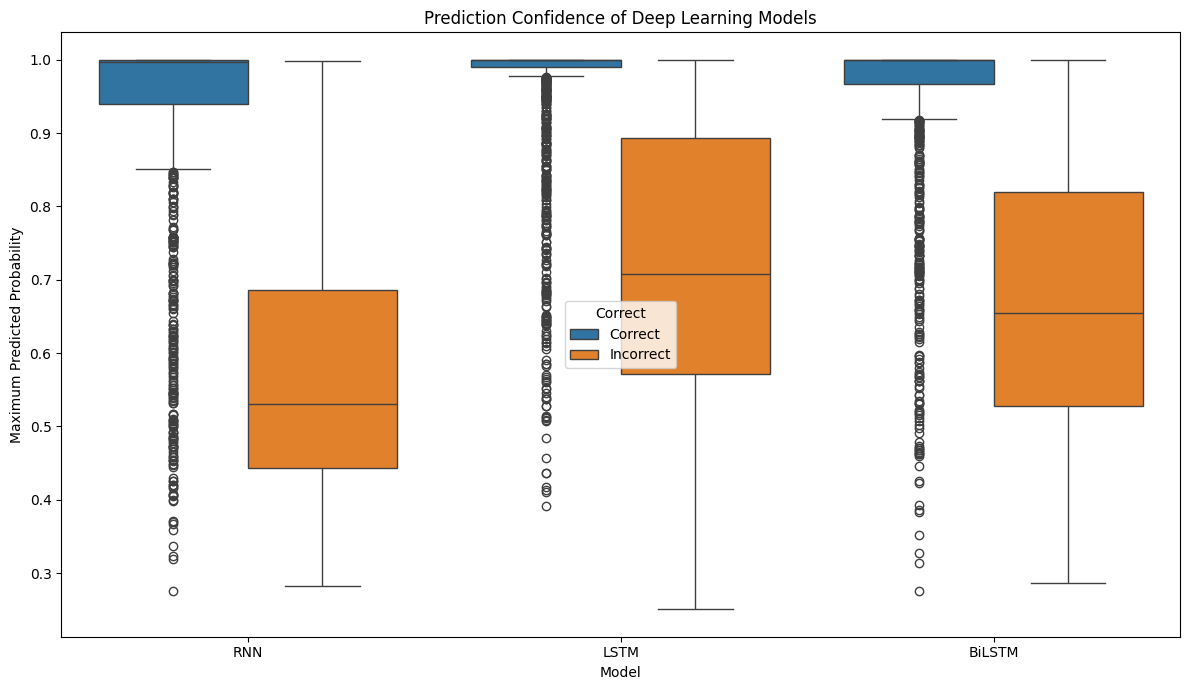

In [43]:
# ============================================================
# PREDICTION CONFIDENCE
# ============================================================

confidence_rows = []

for model_name in models:

    probs = probabilities[model_name]

    confidence = np.max(
        probs,
        axis=1
    )

    correct = (
        predictions[model_name] == y_test
    )

    for c, corr in zip(confidence, correct):

        confidence_rows.append({
            "Model": model_name,
            "Confidence": c,
            "Correct": "Correct" if corr else "Incorrect"
        })

confidence_df = pd.DataFrame(
    confidence_rows
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=confidence_df,
    x="Model",
    y="Confidence",
    hue="Correct"
)

plt.title(
    "Prediction Confidence of Deep Learning Models"
)

plt.ylabel("Maximum Predicted Probability")
plt.xlabel("Model")

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "prediction_confidence.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

error_analysis = {}

for model_name in models:

    preds = predictions[model_name]
    probs = probabilities[model_name]

    error_mask = preds != y_test

    error_df = test_df.loc[
        error_mask
    ].copy()

    error_df["actual_label"] = (
        label_encoder.inverse_transform(
            y_test[error_mask]
        )
    )

    error_df["predicted_label"] = (
        label_encoder.inverse_transform(
            preds[error_mask]
        )
    )

    error_df["confidence"] = np.max(
        probs[error_mask],
        axis=1
    )

    error_df["correct"] = False

    error_analysis[model_name] = error_df

    path = os.path.join(
        ERROR_DIR,
        f"{model_name.lower()}_errors.csv"
    )

    error_df.to_csv(
        path,
        index=False
    )

    print(
        f"{model_name}: "
        f"{len(error_df)} errors"
    )

RNN: 176 errors
LSTM: 134 errors
BiLSTM: 140 errors


In [45]:
# ============================================================
# MOST CONFIDENT WRONG PREDICTIONS
# ============================================================

for model_name in models:

    error_df = error_analysis[model_name]

    if len(error_df) == 0:
        continue

    top_errors = error_df.sort_values(
        "confidence",
        ascending=False
    ).head(20)

    path = os.path.join(
        ERROR_DIR,
        f"{model_name.lower()}_most_confident_errors.csv"
    )

    top_errors.to_csv(
        path,
        index=False
    )

    print("\n")
    print("=" * 80)
    print(model_name)
    print("MOST CONFIDENT WRONG PREDICTIONS")
    print("=" * 80)

    display(
        top_errors[
            [
                TEXT_COL,
                "actual_label",
                "predicted_label",
                "confidence"
            ]
        ]
    )



RNN
MOST CONFIDENT WRONG PREDICTIONS


,text,actual_label,predicted_label,confidence
534,indica o rastreamento. mamas parcialmente lipo...,3,2,0.998509
763,clinical indication screening - first mammogra...,3,2,0.990296
1227,clinical indication tracking. findings partial...,2,1,0.987015
1015,clinical indication tracking. findings heterog...,2,1,0.982890
1317,clinical indication tracking. findings dense b...,3,2,0.975091
566,"clinical indication screening, with family his...",4,2,0.959714
1006,clinical indication tracking. findings dense b...,3,2,0.937780
926,clinical indication tracking. findings breasts...,0,2,0.926306
337,clinical indication tracking. findings breasts...,3,2,0.924739
1333,clinical indication tracking. findings heterog...,2,1,0.921259




LSTM
MOST CONFIDENT WRONG PREDICTIONS


,text,actual_label,predicted_label,confidence
1124,indica o cl nica rastreamentoachados mamas den...,0,2,0.999873
534,indica o rastreamento. mamas parcialmente lipo...,3,2,0.999756
1006,clinical indication tracking. findings dense b...,3,2,0.999635
1166,indica o cl nica rastreamento. achados mamas h...,4,2,0.998699
763,clinical indication screening - first mammogra...,3,2,0.998660
1168,clinical indication investigation of the prima...,0,2,0.998020
470,clinical indication tracking. findings breasts...,3,2,0.994942
671,clinical indication trackingfindings dense bre...,3,2,0.993600
440,clinical indication screening/control of lump(...,3,2,0.992599
551,clinical indication reassessment of changes ob...,1,2,0.992402




BiLSTM
MOST CONFIDENT WRONG PREDICTIONS


,text,actual_label,predicted_label,confidence
534,indica o rastreamento. mamas parcialmente lipo...,3,2,0.999968
1006,clinical indication tracking. findings dense b...,3,2,0.997848
1168,clinical indication investigation of the prima...,0,2,0.986474
763,clinical indication screening - first mammogra...,3,2,0.985199
469,clinical indication tracking. findings heterog...,3,2,0.981789
1166,indica o cl nica rastreamento. achados mamas h...,4,2,0.978243
121,clinical indication tracking. findings partial...,3,2,0.974115
440,clinical indication screening/control of lump(...,3,2,0.973765
551,clinical indication reassessment of changes ob...,1,2,0.973640
470,clinical indication tracking. findings breasts...,3,2,0.967262


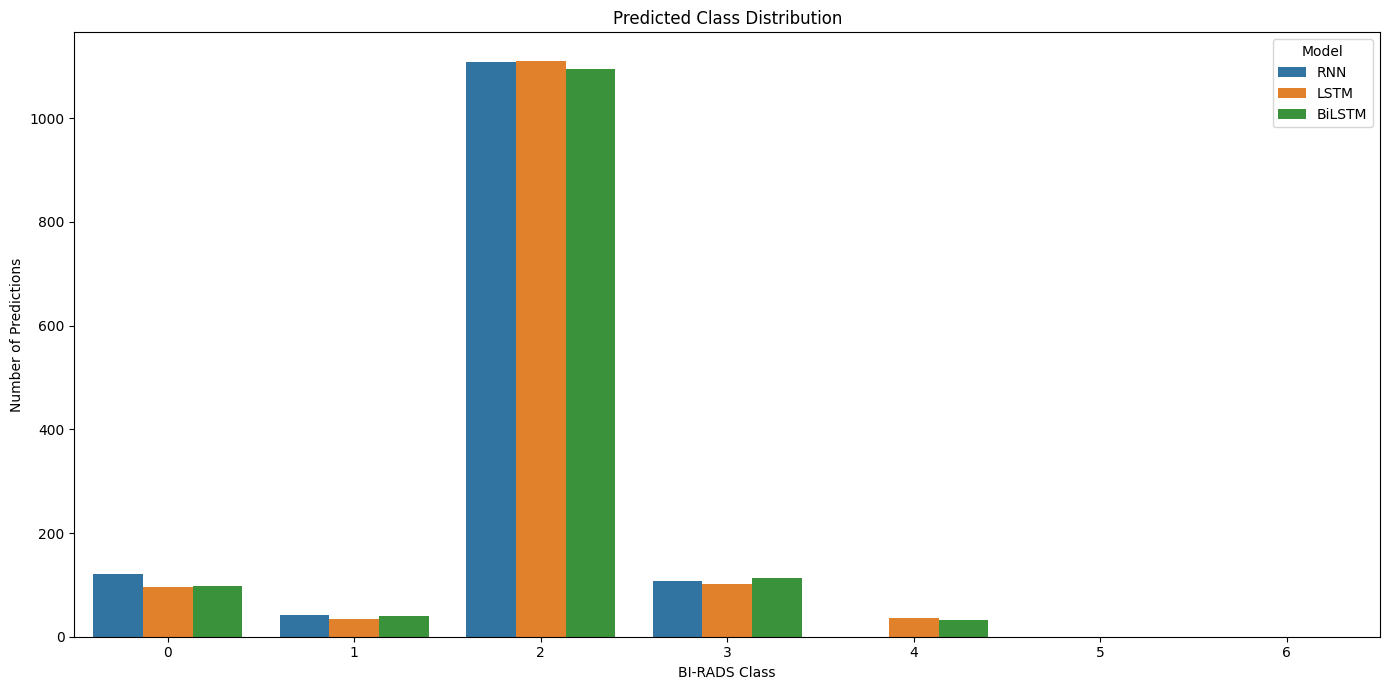

In [46]:
# ============================================================
# PREDICTED CLASS DISTRIBUTION
# ============================================================

distribution_rows = []

for model_name in models:

    preds = predictions[model_name]

    counts = np.bincount(
        preds,
        minlength=len(class_names)
    )

    for i, count in enumerate(counts):

        distribution_rows.append({
            "Model": model_name,
            "Class": class_names[i],
            "Count": count
        })

distribution_df = pd.DataFrame(
    distribution_rows
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=distribution_df,
    x="Class",
    y="Count",
    hue="Model"
)

plt.title(
    "Predicted Class Distribution"
)

plt.xlabel("BI-RADS Class")
plt.ylabel("Number of Predictions")

plt.tight_layout()

path = os.path.join(
    FIG_DIR,
    "predicted_class_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
!pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [49]:
# ============================================================
# SHAP TEXT EXPLAINABILITY
# ============================================================

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [50]:
# ============================================================
# SHAP PREDICTION FUNCTION
# ============================================================

def make_text_predictor(model):

    def predict_text(texts):

        # SHAP may pass a numpy array
        texts = np.asarray(texts).astype(str)

        sequences = tokenizer.texts_to_sequences(
            texts
        )

        padded = pad_sequences(
            sequences,
            maxlen=MAX_LEN,
            padding="post",
            truncating="post"
        )

        return model.predict(
            padded,
            verbose=0
        )

    return predict_text

In [51]:
# ============================================================
# SELECT TEST REPORTS FOR SHAP
# ============================================================

# Number of examples
N_SHAP = 3

shap_texts = (
    test_df[TEXT_COL]
    .astype(str)
    .iloc[:N_SHAP]
    .tolist()
)

for i, text in enumerate(shap_texts):

    print("\n" + "=" * 80)
    print("SHAP SAMPLE", i + 1)
    print("=" * 80)

    print(text[:1500])


SHAP SAMPLE 1
clinical indication tracking. findings partially liposubstituted breasts. punctate and grouped calcifications, measuring less than 1.0 cm, located in the superolateral quadrant of the left breast. the axillary regions do not present significant changes. comparative analysis regarding the examination, no significant changes were observed

SHAP SAMPLE 2
clinical indication tracking. findings breasts with sparse fibroglandular densities. radiopaque marker in the left breast. sparse calcifications. no suspicious calcifications were observed. the axillary regions do not present significant changes. comparative analysis regarding the examination, no significant changes were observed

SHAP SAMPLE 3
clinical indication tracking. positive family history of breast cancer (sister). findings partially liposubstituted breasts. sparse calcifications. no suspicious grouped calcifications were observed. the axillary regions do not present significant changes. comparative analysis previo

In [52]:
# ============================================================
# SHAP EXPLANATIONS
# ============================================================

shap_explainers = {}
shap_values = {}

for model_name in models:

    print("\n" + "=" * 80)
    print("SHAP:", model_name)
    print("=" * 80)

    predictor = make_text_predictor(
        models[model_name]
    )

    masker = shap.maskers.Text(
        tokenizer=r"\W+"
    )

    explainer = shap.Explainer(
        predictor,
        masker
    )

    try:

        explanation = explainer(
            shap_texts
        )

        shap_explainers[model_name] = explainer
        shap_values[model_name] = explanation

        print(
            f"✓ SHAP explanation generated for {model_name}"
        )

    except Exception as e:

        print(
            f"SHAP failed for {model_name}:"
        )

        print(e)


SHAP: RNN


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:40<00:00,  8.44s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:42<00:00, 10.35s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:58, 19.53s/it]

✓ SHAP explanation generated for BiLSTM


In [53]:
# ============================================================
# DISPLAY SHAP TEXT EXPLANATIONS
# ============================================================

for model_name, explanation in shap_values.items():

    print("\n" + "=" * 80)
    print("SHAP EXPLANATION:", model_name)
    print("=" * 80)

    shap.plots.text(
        explanation[0]
    )


SHAP EXPLANATION: RNN



SHAP EXPLANATION: LSTM



SHAP EXPLANATION: BiLSTM


In [54]:
# ============================================================
# SAVE SHAP EXPLANATIONS
# ============================================================

for model_name, explanation in shap_values.items():

    try:

        html = shap.plots.text(
            explanation[0],
            display=False
        )

        html_path = os.path.join(
            SHAP_DIR,
            f"{model_name.lower()}_shap_sample_1.html"
        )

        with open(
            html_path,
            "w",
            encoding="utf-8"
        ) as f:

            f.write(html)

        print("Saved:", html_path)

    except Exception as e:

        print(
            f"Could not save HTML for {model_name}:",
            e
        )

Saved: /content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation/explainability/shap/rnn_shap_sample_1.html
Saved: /content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation/explainability/shap/lstm_shap_sample_1.html
Saved: /content/mydrive/MyDrive/NLP_Research_Project/results/deep_learning_evaluation/explainability/shap/bilstm_shap_sample_1.html


In [55]:
# ============================================================
# SHAP SAMPLE PREDICTIONS
# ============================================================

for model_name in models:

    probs = models[model_name].predict(
        X_test[:N_SHAP],
        verbose=0
    )

    preds = np.argmax(
        probs,
        axis=1
    )

    print("\n", model_name)

    for i in range(N_SHAP):

        print(
            f"Sample {i}: "
            f"Actual={class_names[y_test[i]]}, "
            f"Predicted={class_names[preds[i]]}, "
            f"Confidence={probs[i][preds[i]]:.4f}"
        )


 RNN
Sample 0: Actual=3, Predicted=3, Confidence=0.5468
Sample 1: Actual=2, Predicted=2, Confidence=0.9970
Sample 2: Actual=2, Predicted=2, Confidence=0.9979

 LSTM
Sample 0: Actual=3, Predicted=3, Confidence=0.7409
Sample 1: Actual=2, Predicted=2, Confidence=0.9999
Sample 2: Actual=2, Predicted=2, Confidence=0.9995

 BiLSTM
Sample 0: Actual=3, Predicted=3, Confidence=0.7130
Sample 1: Actual=2, Predicted=2, Confidence=0.9997
Sample 2: Actual=2, Predicted=2, Confidence=0.9996


In [56]:
!pip install -q statsmodels

In [57]:
# ============================================================
# McNEMAR TEST
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(
    y_true,
    pred_a,
    pred_b
):

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    table = np.array([
        [
            np.sum(correct_a & correct_b),
            np.sum(correct_a & ~correct_b)
        ],
        [
            np.sum(~correct_a & correct_b),
            np.sum(~correct_a & ~correct_b)
        ]
    ])

    result = mcnemar(
        table,
        exact=False,
        correction=True
    )

    return table, result.statistic, result.pvalue

In [58]:
# ============================================================
# PAIRWISE McNEMAR TESTS
# ============================================================

from itertools import combinations

statistical_results = []

for model_a, model_b in combinations(
    models.keys(),
    2
):

    table, statistic, pvalue = mcnemar_test(
        y_test,
        predictions[model_a],
        predictions[model_b]
    )

    statistical_results.append({
        "Model A": model_a,
        "Model B": model_b,
        "Statistic": statistic,
        "p_value": pvalue,
        "Significant (p<0.05)": pvalue < 0.05
    })

stats_df = pd.DataFrame(
    statistical_results
)

display(
    stats_df
)

stats_df.to_csv(
    os.path.join(
        STATS_DIR,
        "mcnemar_pairwise_tests.csv"
    ),
    index=False
)

,Model A,Model B,Statistic,p_value,Significant (p<0.05)
0,RNN,LSTM,17.510417,0.000029,True
1,RNN,BiLSTM,14.244186,0.000161,True
2,LSTM,BiLSTM,0.462963,0.496242,False


In [59]:
# ============================================================
# FINAL DL EVALUATION TABLE
# ============================================================

final_table = comparison_df.copy()

final_table = final_table.rename(
    columns={
        "Accuracy": "Accuracy",
        "Precision_macro": "Macro Precision",
        "Recall_macro": "Macro Recall",
        "F1_macro": "Macro F1",
        "F1_weighted": "Weighted F1",
        "ROC_AUC_macro": "Macro ROC-AUC"
    }
)

final_table = final_table[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Macro ROC-AUC"
    ]
]

print("\n" + "=" * 100)
print("FINAL DEEP LEARNING EVALUATION")
print("=" * 100)

display(
    final_table.round(4)
)

final_table.to_csv(
    os.path.join(
        METRICS_DIR,
        "FINAL_DL_EVALUATION_TABLE.csv"
    )
)


FINAL DEEP LEARNING EVALUATION


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro ROC-AUC
BiLSTM,0.8983,0.5245,0.5449,0.5344,0.8962,0.9656
LSTM,0.9027,0.5303,0.5326,0.5309,0.8988,0.9712
RNN,0.8722,0.3944,0.4327,0.4114,0.8608,0.9487
